## POKEMON

In [ ]:
models/pokemon_model.pkl

## TASK 1 - Data Understanding and Exploration

In [108]:
import pandas as pd
import numpy as np

df = pd.read_csv("G2.csv")
df.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58


In [109]:
df.shape

(1351, 10)

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   str    
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   str    
 6   type_2           765 non-null    str    
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
dtypes: float64(1), int64(6), str(3)
memory usage: 105.7 KB


In [111]:
print("Categorical_Features:", df.select_dtypes(include=['object', 'string']).columns)
print("Numerical_Features:", df.select_dtypes(include='number').columns.tolist())

Categorical_Features: Index(['name', 'type_1', 'type_2'], dtype='str')
Numerical_Features: ['id', 'height_dm', 'weight_hg', 'base_experience', 'hp', 'attack', 'defense']


In [112]:
df.duplicated().sum()

np.int64(0)

No Duplicates were found

In [113]:
df.isnull().sum()

id                   0
name                 0
height_dm            0
weight_hg            0
base_experience     49
type_1               0
type_2             586
hp                   0
attack               0
defense              0
dtype: int64

There are missing values in base_experience and type_2 features

In [114]:
df.describe()

,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [115]:
summary_stats = df.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
id,1351.0,2841.692080,4139.019112,1.0,338.5,676.0,1013.5,10326.0
height_dm,1351.0,20.443375,53.238467,1.0,6.0,11.0,17.0,1000.0
weight_hg,1351.0,991.059956,1953.115812,0.0,94.5,326.0,853.5,10000.0
base_experience,1302.0,161.943932,82.532554,36.0,71.0,165.0,222.5,608.0
hp,1351.0,71.673575,26.827529,1.0,55.0,70.0,85.0,255.0
attack,1351.0,82.757957,32.351906,5.0,60.0,80.0,102.5,190.0
defense,1351.0,76.193930,30.712902,5.0,55.0,70.0,95.0,250.0


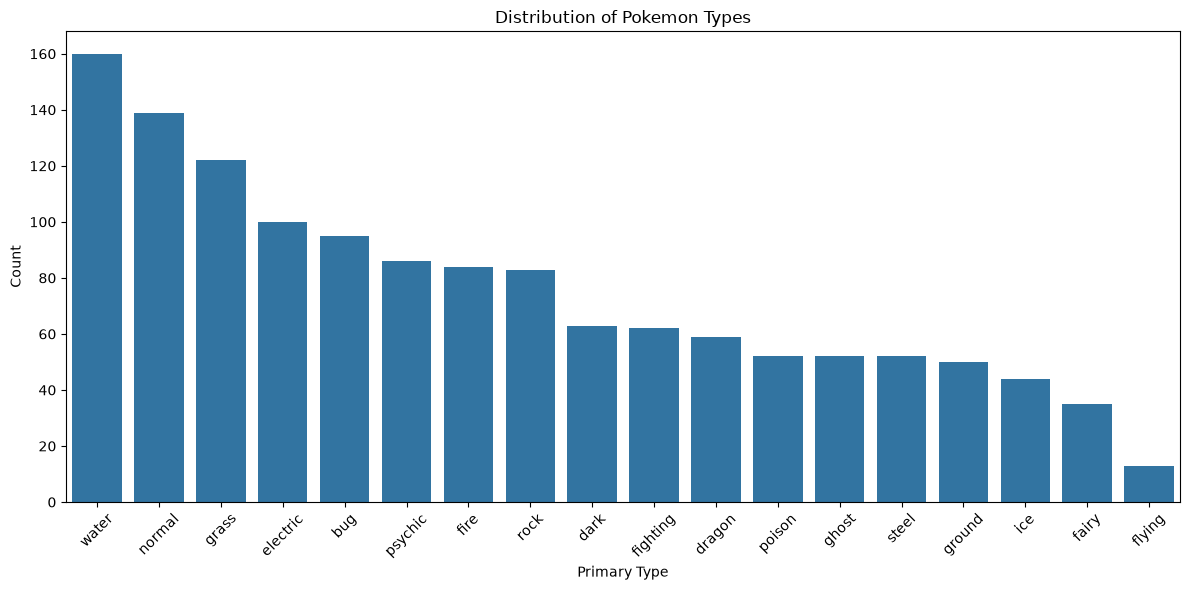

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='type_1', order=df['type_1'].value_counts().index)
plt.title('Distribution of Pokemon Types')
plt.xlabel('Primary Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


1) The Most Frequent Primary Type is: "Water" with 160 pokemon

2) The feature with the largest variation is: weight_hg because it has the highest standard deviation.Id also have std high, but it is ignored because its an identifier not a feature.

3) The dataset contains both numerical and categorical variables, with type_1 and type_2 as type labels, an uneven distrbution of Pokémon types are dominated by water, normal and grass andmix of physical and combat features which is useful for predicting the primary type using a classification model.

## TASK 2 - Data Preprocessing

In [117]:
df.isnull().sum()

id                   0
name                 0
height_dm            0
weight_hg            0
base_experience     49
type_1               0
type_2             586
hp                   0
attack               0
defense              0
dtype: int64

In [118]:
df['base_experience'] = df['base_experience'].fillna(df['base_experience'].median())
df['type_2'] = df['type_2'].fillna(df['type_2'].mode()[0])

In [119]:
df.isnull().sum()

id                 0
name               0
height_dm          0
weight_hg          0
base_experience    0
type_1             0
type_2             0
hp                 0
attack             0
defense            0
dtype: int64

Missing values are treated by using median() and mode().In base_experience column which is a numerical feature, median was used because it is highly resistant to outliers.In type_2, since it is a categorical feature, mode() was used.

In [120]:
Y = df['type_1']
X = df.drop(columns=['id', 'name', 'type_1'])

Selected type_1 feature as Target.
id,name are removed because both are non usefulll, id is an identifier and name is not a useful feature for model training.

In [121]:
X = pd.get_dummies(X, columns=['type_2'], drop_first=False)

In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Y_train shape:', Y_train.shape)
print('Y_test shape:', Y_test.shape)

X_train.head()

X_train shape: (1080, 24)
X_test shape: (271, 24)
Y_train shape: (1080,)
Y_test shape: (271,)


,height_dm,weight_hg,base_experience,hp,attack,defense,type_2_bug,type_2_dark,type_2_dragon,type_2_electric,...,type_2_ghost,type_2_grass,type_2_ground,type_2_ice,type_2_normal,type_2_poison,type_2_psychic,type_2_rock,type_2_steel,type_2_water
489,3,14,270.0,100,100,100,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
205,15,140,145.0,100,70,70,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
397,12,249,218.0,85,120,70,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1081,12,490,198.0,65,150,60,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
133,10,290,184.0,130,65,60,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


##Analytics 

1). Preprocessing is important because machine learning models can only work with clean, consistent, and numerical data, it doesn't work with categorical datas.Without preprocessing the model may crash or create poor results
missing values can cause errors.Thats why preprocessing is essential before model training.

2). I filled the missing values in type_2 using the mode() function.Because type_2 is a categorical column, and the mode is the most frequent value in that column.By filling it with mode it makes the column realistic rather creating unrealistic data.

## TASK 3 - Exploitory Data Analysis (EDA)

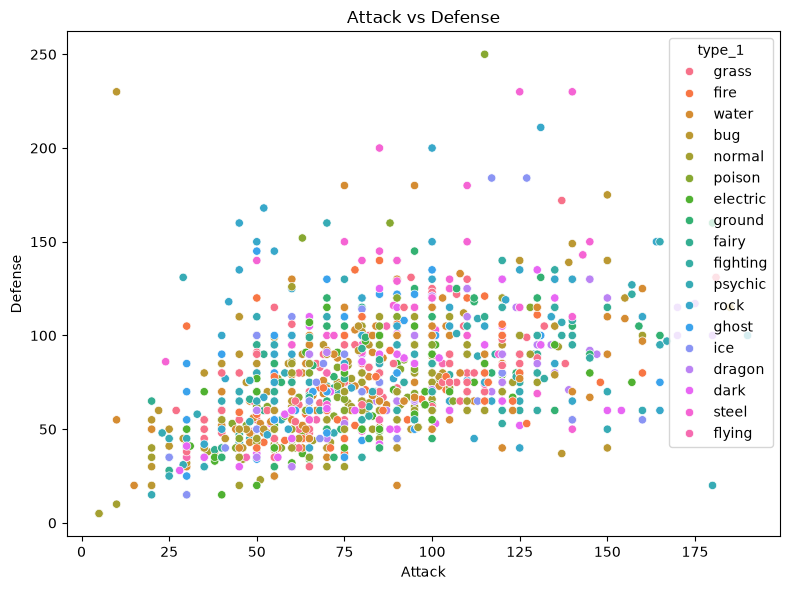

In [123]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='attack', y='defense', hue='type_1')
plt.title('Attack vs Defense')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.tight_layout()
plt.show()

Insight - Pokemon with higher attack often have higher defense.

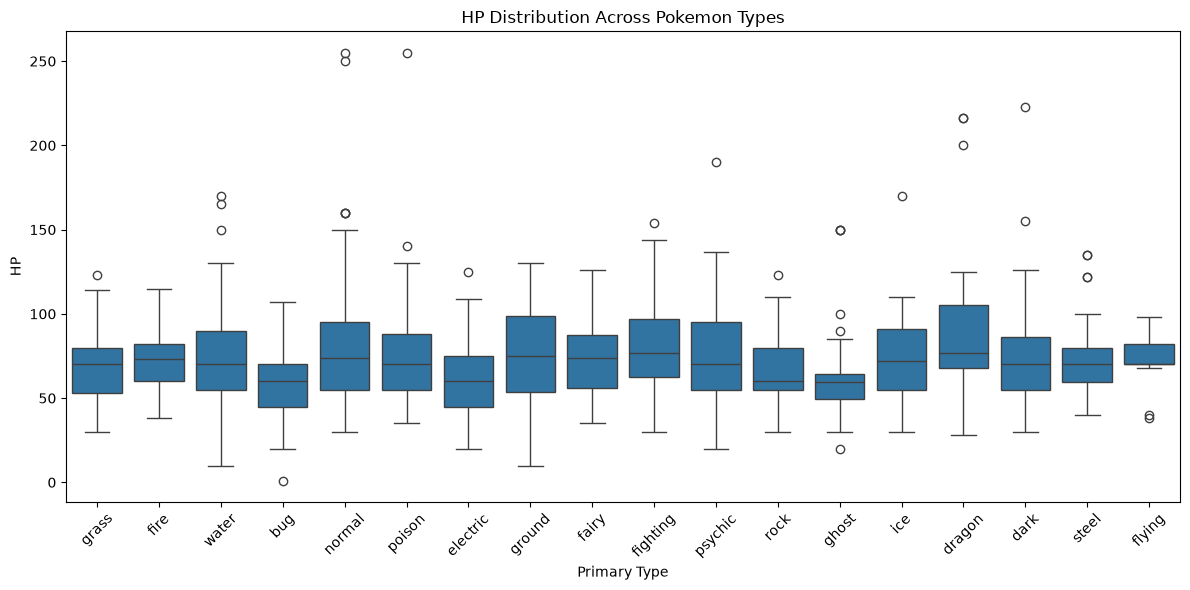

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='type_1', y='hp')
plt.title('HP Distribution Across Pokemon Types')
plt.xlabel('Primary Type')
plt.ylabel('HP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

insight - Dragon, ground, and fighting Pokémon generally have higher HP values, while bug Pokemon tend to have lower HP

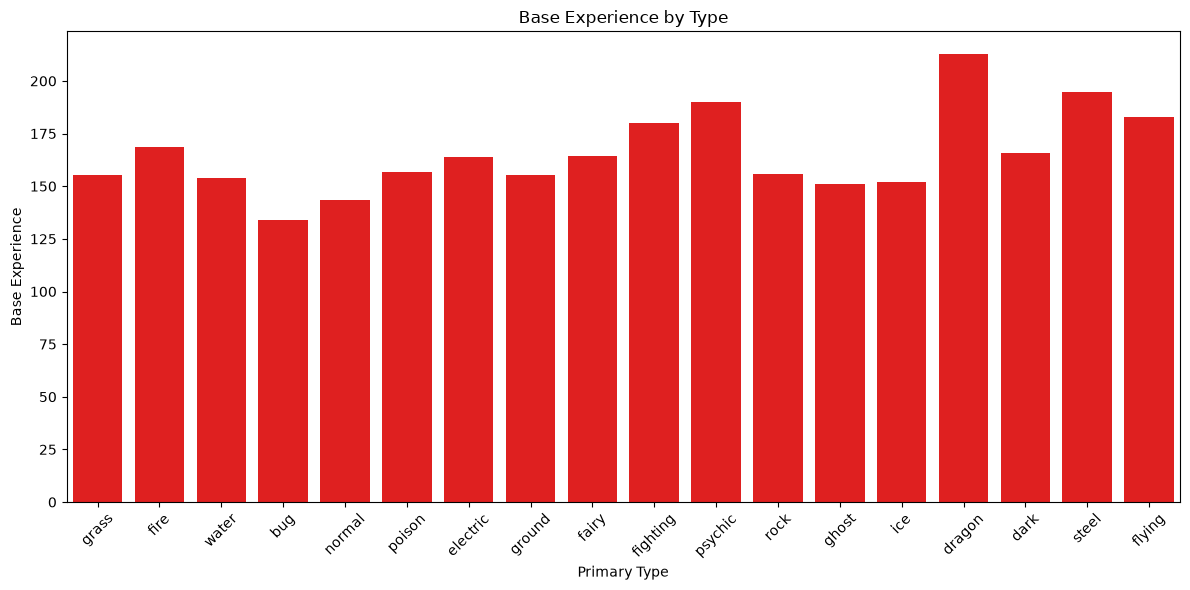

In [136]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='type_1', y='base_experience', estimator='mean', errorbar=None,color = 'red')
plt.title('Base Experience by Type')
plt.xlabel('Primary Type')
plt.ylabel('Base Experience')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

insight - Dragon Pokemon have the highest average base experience, while bug Pokemon have the lowest

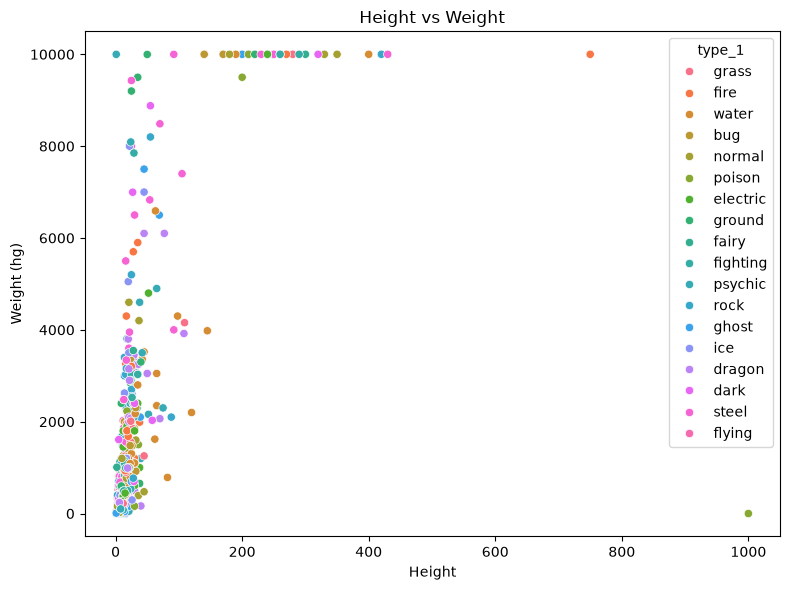

In [139]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='height_dm', y='weight_hg', hue='type_1')
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight (hg)')
plt.tight_layout()
plt.show()

insight - Height and weight show a general positive relationship

## Analysis

1) Fighting type of pokemon tends to have the highest average attack

2) height and weight show a positive relationship, as height increases, weight generally increases.

3) Most useful features for distinguishing Pokémon types are Defense, HP,Weight,Height.Because these features show clear differences across type groups in the visualizations 

## Task 4 - Machine Learning Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

lr_pipe.fit(X_train, Y_train)
y_pred_lr = lr_pipe.predict(X_test)

Logistic Regression Accuracy: 0.19557195571955718
              precision    recall  f1-score   support

         bug       0.20      0.11      0.14        19
        dark       0.50      0.15      0.24        13
      dragon       0.22      0.17      0.19        12
    electric       0.22      0.30      0.26        20
       fairy       0.00      0.00      0.00         7
    fighting       0.10      0.08      0.09        12
        fire       0.08      0.06      0.07        17
      flying       0.00      0.00      0.00         3
       ghost       0.20      0.10      0.13        10
       grass       0.20      0.08      0.11        25
      ground       0.00      0.00      0.00        10
         ice       1.00      0.11      0.20         9
      normal       0.28      0.75      0.40        28
      poison       0.00      0.00      0.00        10
     psychic       0.07      0.06      0.06        17
        rock       0.12      0.18      0.14        17
       steel       0.29      0.

In [157]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)

y_pred_dt = dt.predict(X_test)

In [158]:
print('Decision Tree Accuracy:', accuracy_score(Y_test, y_pred_dt))
print(classification_report(Y_test, y_pred_dt))

Decision Tree Accuracy: 0.2066420664206642
              precision    recall  f1-score   support

         bug       0.22      0.21      0.22        19
        dark       0.00      0.00      0.00        13
      dragon       0.20      0.17      0.18        12
    electric       0.40      0.40      0.40        20
       fairy       0.17      0.14      0.15         7
    fighting       0.21      0.33      0.26        12
        fire       0.20      0.24      0.22        17
      flying       0.00      0.00      0.00         3
       ghost       0.11      0.10      0.11        10
       grass       0.20      0.20      0.20        25
      ground       0.11      0.10      0.11        10
         ice       0.22      0.22      0.22         9
      normal       0.35      0.29      0.31        28
      poison       0.10      0.10      0.10        10
     psychic       0.19      0.18      0.18        17
        rock       0.38      0.35      0.36        17
       steel       0.12      0.20     

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificatio

In [159]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, Y_train)
y_pred_rf = rf.predict(X_test)

In [170]:
print('Random forest Accuracy:', accuracy_score(Y_test, y_pred_rf))
print(classification_report(Y_test, y_pred_rf))

Random forest Accuracy: 0.3062730627306273
              precision    recall  f1-score   support

         bug       0.29      0.37      0.33        19
        dark       0.57      0.31      0.40        13
      dragon       0.23      0.25      0.24        12
    electric       0.39      0.35      0.37        20
       fairy       0.50      0.29      0.36         7
    fighting       0.25      0.25      0.25        12
        fire       0.18      0.24      0.21        17
      flying       0.00      0.00      0.00         3
       ghost       0.33      0.20      0.25        10
       grass       0.38      0.40      0.39        25
      ground       0.67      0.20      0.31        10
         ice       0.00      0.00      0.00         9
      normal       0.42      0.50      0.46        28
      poison       0.12      0.10      0.11        10
     psychic       0.27      0.18      0.21        17
        rock       0.38      0.35      0.36        17
       steel       0.42      0.50     

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificatio

In [164]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_tuned = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

best_rf = grid_search.best_estimator_
y_pred_tuned_rf = best_rf.predict(X_test)

In [166]:
print('Best Random Forest Parameters:', grid_search.best_params_)
print('Tuned Random Forest Accuracy:', accuracy_score(Y_test, y_pred_tuned_rf))
print('Precision:', precision_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0))
print('Recall:', recall_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0))
print('F1 Score:', f1_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0))
print(classification_report(Y_test, y_pred_tuned_rf))

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Accuracy: 0.3025830258302583
Precision: 0.32984392151058817
Recall: 0.2620739466501851
F1 Score: 0.27558133042529404
              precision    recall  f1-score   support

         bug       0.32      0.37      0.34        19
        dark       0.60      0.23      0.33        13
      dragon       0.30      0.25      0.27        12
    electric       0.39      0.35      0.37        20
       fairy       0.67      0.29      0.40         7
    fighting       0.23      0.25      0.24        12
        fire       0.19      0.24      0.21        17
      flying       0.00      0.00      0.00         3
       ghost       0.40      0.20      0.27        10
       grass       0.32      0.36      0.34        25
      ground       0.67      0.20      0.31        10
         ice       0.00      0.00      0.00         9
      normal       0.39      0.50      0.

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificatio

In [169]:
results = [
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(Y_test, y_pred_lr),
        'Precision': precision_score(Y_test, y_pred_lr, average='macro', zero_division=0),
        'Recall': recall_score(Y_test, y_pred_lr, average='macro', zero_division=0),
        'F1 Score': f1_score(Y_test, y_pred_lr, average='macro', zero_division=0)
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(Y_test, y_pred_dt),
        'Precision': precision_score(Y_test, y_pred_dt, average='macro', zero_division=0),
        'Recall': recall_score(Y_test, y_pred_dt, average='macro', zero_division=0),
        'F1 Score': f1_score(Y_test, y_pred_dt, average='macro', zero_division=0)
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(Y_test, y_pred_rf),
        'Precision': precision_score(Y_test, y_pred_rf, average='macro', zero_division=0),
        'Recall': recall_score(Y_test, y_pred_rf, average='macro', zero_division=0),
        'F1 Score': f1_score(Y_test, y_pred_rf, average='macro', zero_division=0)
    },
    {
        'Model': 'Tuned Random Forest',
        'Accuracy': accuracy_score(Y_test, y_pred_tuned_rf),
        'Precision': precision_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0),
        'Recall': recall_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0),
        'F1 Score': f1_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0)
    }
]

comparison_table = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print(comparison_table.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
Tuned Random Forest  0.302583   0.329844 0.262074  0.275581
      Random Forest  0.306273   0.311000 0.266057  0.274321
      Decision Tree  0.206642   0.182971 0.186168  0.182852
Logistic Regression  0.195572   0.200809 0.151769  0.140384


Random Forest and Tuned Random Forest performed almost equally, with Tuned Random Forest having the highest F1-score and Random Forest the highest accuracy.

Selecting Tuned Random Forest Model as Final model because, for a multi-class classification task, F1-score is the better than accuracy

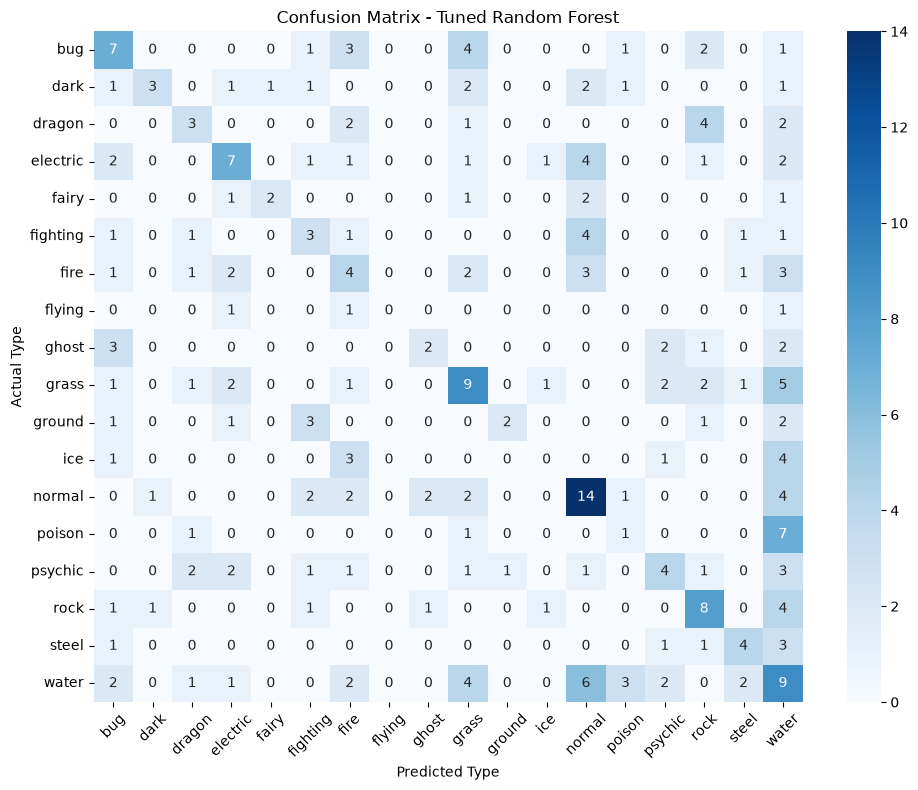

In [173]:
from sklearn.metrics import confusion_matrix

best_model = best_rf
best_predictions = y_pred_tuned_rf

labels = sorted(Y_test.unique())
cm = confusion_matrix(Y_test, best_predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted Type')
plt.ylabel('Actual Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [174]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nTop 10 Most Influential Features:')
print(feature_importance.head(10).to_string(index=False))


Top 10 Most Influential Features:
        Feature  Importance
      weight_hg    0.157213
base_experience    0.154857
         attack    0.147754
        defense    0.142266
             hp    0.138979
      height_dm    0.124942
  type_2_flying    0.020699
   type_2_steel    0.009044
   type_2_fairy    0.008945
  type_2_dragon    0.008677


## Analysis

1) The Tuned Random Forest achieved the best performance because it had the highest F1-score among the evaluated models.Selecting Tuned Random Forest Model as Final model because, for a multi-class classification task, F1-score is the better than accuracy.

2) The most frequently misclassified Pokémon types were those with overlapping stats and fewer samples, especially water, normal, grass, fire, and fighting.

3) Some types are harder to predict because HP, attack, defense, height, and weight, and many of them have fewer examples in the dataset.

In [ ]:
# Save the complete preprocessing and model pipeline for Flask deployment
import os
import pickle
from sklearn.impute import SimpleImputer


flask_feature_columns = [
    "hp",
    "attack",
    "defense",
    "height_dm",
    "weight_hg",
    "base_experience",
]

flask_training_data = df[flask_feature_columns + ["type_1"]].copy()
X_flask = flask_training_data[flask_feature_columns]
y_flask = flask_training_data["type_1"]

flask_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                max_depth=20,
                min_samples_leaf=1,
            ),
        ),
    ]
)

flask_pipeline.fit(X_flask, y_flask)
os.makedirs("models", exist_ok=True)

with open("models/pokemon_pipeline.pkl", "wb") as file:
    pickle.dump(
        {
            "pipeline": flask_pipeline,
            "features": flask_feature_columns,
            "target": "type_1",
            "classes": sorted(y_flask.unique().tolist()),
        },
        file,
    )

print("Saved models/pokemon_pipeline.pkl")

Saved models/pokemon_pipeline.pkl
The file contains: median imputer, StandardScaler, Random Forest, feature order, and class labels.


## Analysis

1).It can help developers estimate a Pokemon’s likely type from its base statistics during game design.It can help players understand Pokemon statistics and support team-building or strategy decisions.

2).The predictions are estimates because the model uses only six statistics and does not consider moves, abilities, appearance, or secondary type.Prediction accuracy may be limited because some Pokémon types have similar statistics.
